
# ASVspoof5 All-Data (train/dev/eval) Logistic Regression: Bonafide vs Spoof (Low-Disk Streaming)

This notebook trains a binary logistic model using **all Track-1 data**:
- `train` protocol -> model training
- `dev` protocol -> threshold selection / validation
- `eval` protocol -> final test

Low-disk design:
- Reads audio directly from tar members
- Extracts only needed members, processes immediately, does **not** keep extracted audio files
- Optional prediction CSV export is disabled by default to save disk


In [1]:

import io
import gc
import json
import pickle
import tarfile
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torchaudio
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report


In [2]:

# ===== Config =====
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROJECT_ROOT = Path('/home/SpeakerRec/BioVoice')

DATA_ROOT = PROJECT_ROOT / 'data' / 'datasets' / 'ASVspoof5_tars'
PROTOCOL_DIR = DATA_ROOT / 'ASVspoof5_protocols'

PROTOCOL_PATHS = {
    'train': PROTOCOL_DIR / 'ASVspoof5.train.tsv',
    'dev': PROTOCOL_DIR / 'ASVspoof5.dev.track_1.tsv',
    'eval': PROTOCOL_DIR / 'ASVspoof5.eval.track_1.tsv',
}

TAR_DIRS = {
    'train': DATA_ROOT / 'ASVspoof5_audio_train_tars',
    'dev': DATA_ROOT / 'ASVspoof5_audio_dev_tars',
    'eval': DATA_ROOT / 'ASVspoof5_audio_eval_tars',
}

# Large chunk gives better throughput; reduce if RAM is tight.
CHUNK_SIZE = 1024
THRESH_GRID = np.linspace(0.05, 0.95, 181)
RANDOM_SEED = 42

# Safety switch for debugging only. Keep None for full data.
MAX_ROWS_PER_SPLIT = None

SAVE_PREDICTIONS = False

OUT_DIR = PROJECT_ROOT / 'data' / 'models' / 'asvspoof5_all_data_train_dev_eval_streaming_binary'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('DEVICE:', DEVICE)
print('PROTOCOL_DIR:', PROTOCOL_DIR)
for k,v in PROTOCOL_PATHS.items():
    print(f'PROTOCOL[{k}] = {v} | exists =', v.exists())
for k,v in TAR_DIRS.items():
    print(f'TARS[{k}] = {v} | exists =', v.exists())
print('OUT_DIR:', OUT_DIR)


DEVICE: cuda
PROTOCOL_DIR: /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols
PROTOCOL[train] = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/ASVspoof5.train.tsv | exists = True
PROTOCOL[dev] = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/ASVspoof5.dev.track_1.tsv | exists = True
PROTOCOL[eval] = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/ASVspoof5.eval.track_1.tsv | exists = True
TARS[train] = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_audio_train_tars | exists = True
TARS[dev] = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_audio_dev_tars | exists = True
TARS[eval] = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_audio_eval_tars | exists = True
OUT_DIR: /home/SpeakerRec/BioVoice/data/models/asvspoof5_all_data_train_dev_eval_streaming_binary


In [3]:

# ===== Load protocol metadata =====
COLS = ['speaker_id','utt_id','gender','c4','c5','c6','codec_id','system_id','label','unused']
LABEL_MAP = {'bonafide': 0, 'spoof': 1}


def load_protocol(path: Path, split_name: str) -> pd.DataFrame:
    assert path.exists(), f'Missing protocol file: {path}'
    df = pd.read_csv(path, sep=r'\s+', header=None, names=COLS, engine='python')
    df['split'] = split_name
    df['label'] = df['label'].astype(str)
    df['label_id'] = df['label'].map(LABEL_MAP).astype(int)
    return df[['split','speaker_id','utt_id','label','label_id','system_id','codec_id']]

train_df = load_protocol(PROTOCOL_PATHS['train'], 'train')
val_df = load_protocol(PROTOCOL_PATHS['dev'], 'val')
test_df = load_protocol(PROTOCOL_PATHS['eval'], 'test')

if MAX_ROWS_PER_SPLIT is not None:
    train_df = train_df.head(MAX_ROWS_PER_SPLIT).copy()
    val_df = val_df.head(MAX_ROWS_PER_SPLIT).copy()
    test_df = test_df.head(MAX_ROWS_PER_SPLIT).copy()

for name, df in [('train',train_df), ('val',val_df), ('test',test_df)]:
    print(f'[{name}] rows={len(df):,} speakers={df.speaker_id.nunique():,} labels=', df['label'].value_counts().to_dict())

meta_out = pd.concat([train_df, val_df, test_df], ignore_index=True)
meta_out.to_csv(OUT_DIR / 'all_data_manifest_used.csv', index=False)


[train] rows=182,357 speakers=400 labels= {'spoof': 163560, 'bonafide': 18797}
[val] rows=140,950 speakers=785 labels= {'spoof': 109616, 'bonafide': 31334}
[test] rows=680,774 speakers=737 labels= {'spoof': 542086, 'bonafide': 138688}


In [4]:

# ===== Load ReDimNet =====
redim_model = (
    torch.hub.load(
        'IDRnD/ReDimNet',
        'ReDimNet',
        model_name='b5',
        train_type='ptn',
        dataset='vox2',
    )
    .to(DEVICE)
    .eval()
)
print('Loaded ReDimNet on', DEVICE)


Using cache found in /home/SpeakerRec/.cache/torch/hub/IDRnD_ReDimNet_master


Loaded ReDimNet on cuda


In [9]:
# ===== Streaming helpers: read tar member -> embedding, chunked =====


def tar_files_for_split(split_name: str):
    # map notebook split names -> tar partition names
    part = {"train": "train", "val": "dev", "test": "eval"}[split_name]
    tdir = TAR_DIRS[part]
    assert tdir.exists(), f"Missing tar dir: {tdir}"

    if split_name == "train":
        pats = ["flac_T_*.tar"]
    elif split_name == "val":
        pats = ["flac_D_*.tar"]
    else:  # test
        pats = ["flac_E_*.tar"]

    out = []
    for p in pats:
        out.extend(sorted(tdir.glob(p)))
    assert len(out) > 0, f"No tar files found for split={split_name} under {tdir}"
    return out


def embed_waveform(wav: torch.Tensor, sr: int, model, device: str):
    if sr != 16000:
        wav = torchaudio.functional.resample(wav, sr, 16000)
    if wav.ndim == 1:
        wav = wav.unsqueeze(0)
    if wav.shape[0] > 1:
        wav = wav[:1, :]
    wav = wav.to(device)
    with torch.no_grad():
        emb = model(wav)
    return emb.squeeze(0).detach().cpu().numpy().astype(np.float32)


def embed_member_from_tar(tf: tarfile.TarFile, member: tarfile.TarInfo, model, device: str):
    fobj = tf.extractfile(member)
    if fobj is None:
        raise RuntimeError(f'Cannot extract member: {member.name}')
    raw = fobj.read()

    # Prefer in-memory decode (no disk). Fallback to tmp file if backend needs a path.
    try:
        wav, sr = torchaudio.load(io.BytesIO(raw))
    except Exception:
        suffix = Path(member.name).suffix or '.flac'
        with tempfile.NamedTemporaryFile(suffix=suffix, delete=True) as tmp:
            tmp.write(raw)
            tmp.flush()
            wav, sr = torchaudio.load(tmp.name)

    return embed_waveform(wav, sr, model, device)


def iter_embedding_chunks_from_tars(split_name: str, split_df: pd.DataFrame, model, device: str, chunk_size: int = 1024):
    # Map utt_id -> row metadata, used to filter exact required set.
    rec_map = {str(r.utt_id): (int(r.label_id), str(r.speaker_id), str(r.system_id), str(r.label)) for r in split_df.itertuples(index=False)}
    need = set(rec_map.keys())
    found = set()

    X_chunk, y_chunk, meta_chunk = [], [], []

    tars = tar_files_for_split(split_name)
    print(f'[{split_name}] tar files:', len(tars))

    for tar_path in tars:
        print(f'[{split_name}] reading', tar_path.name)
        with tarfile.open(tar_path, 'r') as tf:
            for m in tf:
                if not m.isfile():
                    continue
                utt = Path(Path(m.name).name).stem
                if utt not in need:
                    continue

                emb = embed_member_from_tar(tf, m, model, device)
                label_id, speaker_id, system_id, label = rec_map[utt]

                X_chunk.append(emb)
                y_chunk.append(label_id)
                meta_chunk.append((utt, speaker_id, system_id, label, split_name))
                found.add(utt)

                if len(X_chunk) >= chunk_size:
                    yield np.stack(X_chunk).astype(np.float32), np.array(y_chunk, dtype=np.int64), meta_chunk
                    X_chunk, y_chunk, meta_chunk = [], [], []

        print(f'[{split_name}] found so far: {len(found):,}/{len(need):,}')

    if X_chunk:
        yield np.stack(X_chunk).astype(np.float32), np.array(y_chunk, dtype=np.int64), meta_chunk

    missing = need - found
    if missing:
        ex = sorted(list(missing))[:10]
        raise RuntimeError(f'[{split_name}] missing {len(missing)} utt_ids in tar files. examples={ex}')

In [6]:
# ===== Build full embedding arrays, then train LogisticRegression =====


def collect_split_arrays(split_name: str, split_df: pd.DataFrame):
    Xs = []
    ys = []
    metas = []
    for Xb, yb, meta in tqdm(iter_embedding_chunks_from_tars(split_name, split_df, redim_model, DEVICE, CHUNK_SIZE), desc=f'Collect embeddings({split_name})'):
        Xs.append(Xb)
        ys.append(yb)
        metas.extend(meta)
        del Xb, yb
        gc.collect()
    X = np.concatenate(Xs, axis=0).astype(np.float32)
    y = np.concatenate(ys, axis=0).astype(np.int64)
    return X, y, metas


X_train, y_train, meta_train = collect_split_arrays('train', train_df)
X_val, y_val, meta_val = collect_split_arrays('val', val_df)
X_test, y_test, meta_test = collect_split_arrays('test', test_df)

print('X_train:', X_train.shape, 'X_val:', X_val.shape, 'X_test:', X_test.shape)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(
    max_iter=2000,
    C=1.0,
    class_weight=None,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
clf.fit(X_train_s, y_train)

print('Training complete (LogisticRegression).')


Collect embeddings(train): 0it [00:00, ?it/s]

[train] tar files: 5
[train] reading flac_T_aa.tar


Collect embeddings(train): 35it [57:23, 99.72s/it] 

[train] found so far: 36,500/182,357
[train] reading flac_T_ab.tar


Collect embeddings(train): 71it [1:57:21, 98.88s/it] 

...

[val] found so far: 94,800/140,950
[val] reading flac_D_ac.tar


Collect embeddings(val): 138it [2:51:38, 67.29s/it]

[val] found so far: 140,950/140,950


Collect embeddings(val): 138it [2:51:38, 74.63s/it]
Collect embeddings(test): 0it [00:01, ?it/s]


KeyError: 'test'

In [10]:
# continue from preserved state
X_test, y_test, meta_test = collect_split_arrays("test", test_df)

print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(
    max_iter=2000,
    C=1.0,
    class_weight=None,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
clf.fit(X_train_s, y_train)

print("Training complete (LogisticRegression).")

Collect embeddings(test): 0it [00:00, ?it/s]

[test] tar files: 10
[test] reading flac_E_aa.tar


Collect embeddings(test): 66it [1:28:00, 80.11s/it]

[test] found so far: 68,188/680,774
[test] reading flac_E_ab.tar


Collect embeddings(test): 133it [2:58:06, 81.77s/it]

...

[test] found so far: 613,692/680,774
[test] reading flac_E_aj.tar


Collect embeddings(test): 664it [14:40:20, 79.20s/it]

[test] found so far: 680,774/680,774


Collect embeddings(test): 665it [14:41:29, 79.53s/it]


X_train: (182357, 192) X_val: (140950, 192) X_test: (680774, 192)
Training complete (LogisticRegression).


In [11]:
# ===== Validation threshold tuning + test evaluation =====


def metrics_at_threshold(y_true, p1, thr):
    y_hat = (p1 >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat).tolist()
    out = {
        'threshold': float(thr),
        'accuracy': float(accuracy_score(y_true, y_hat)),
        'auc': float(roc_auc_score(y_true, p1)) if len(np.unique(y_true)) == 2 else None,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_true, y_hat, output_dict=True, zero_division=0),
    }
    tn, fp = cm[0]
    fn, tp = cm[1]
    tnr = tn / (tn + fp) if (tn + fp) else 0.0
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    out['balanced_accuracy'] = float((tnr + tpr) / 2.0)
    out['bonafide_recall'] = float(tnr)
    out['spoof_recall'] = float(tpr)
    return out


p_train = clf.predict_proba(X_train_s)[:, 1]
p_val = clf.predict_proba(X_val_s)[:, 1]
p_test = clf.predict_proba(X_test_s)[:, 1]

best = None
for thr in THRESH_GRID:
    m = metrics_at_threshold(y_val, p_val, float(thr))
    key = (m['balanced_accuracy'], m['accuracy'], m['auc'] if m['auc'] is not None else -1.0)
    row = {'threshold': float(thr), 'val_balanced_accuracy': m['balanced_accuracy'], 'val_accuracy': m['accuracy'], 'val_auc': m['auc'], 'val_bonafide_recall': m['bonafide_recall'], 'val_spoof_recall': m['spoof_recall']}
    if best is None or key > best['_key']:
        best = {'_key': key, **row}

chosen_thr = float(best['threshold'])
print('Chosen threshold from val:', chosen_thr)

metrics_train = metrics_at_threshold(y_train, p_train, chosen_thr)
metrics_test_tuned = metrics_at_threshold(y_test, p_test, chosen_thr)
metrics_test_05 = metrics_at_threshold(y_test, p_test, 0.5)

summary = {
    'setup': {
        'train_split': 'ASVspoof5.train.tsv',
        'val_split': 'ASVspoof5.dev.track_1.tsv',
        'test_split': 'ASVspoof5.eval.track_1.tsv',
        'model': 'LogisticRegression + StandardScaler',
        'chunk_size': CHUNK_SIZE,
    },
    'best_params': best,
    'metrics_train_tuned_threshold': metrics_train,
    'metrics_test_tuned_threshold': metrics_test_tuned,
    'metrics_test_default_threshold_0_5': metrics_test_05,
}

(OUT_DIR / 'run_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
with open(OUT_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(OUT_DIR / 'logistic_regression.pkl', 'wb') as f:
    pickle.dump(clf, f)

if SAVE_PREDICTIONS:
    train_pred_df = pd.DataFrame(meta_train, columns=['utt_id','speaker_id','system_id','label_str','split'])
    val_pred_df = pd.DataFrame(meta_val, columns=['utt_id','speaker_id','system_id','label_str','split'])
    test_pred_df = pd.DataFrame(meta_test, columns=['utt_id','speaker_id','system_id','label_str','split'])
    train_pred_df['label_id'] = y_train
    val_pred_df['label_id'] = y_val
    test_pred_df['label_id'] = y_test
    train_pred_df['prob_spoof'] = p_train
    val_pred_df['prob_spoof'] = p_val
    test_pred_df['prob_spoof'] = p_test
    pred_all = pd.concat([train_pred_df, val_pred_df, test_pred_df], ignore_index=True)
    pred_all.to_csv(OUT_DIR / 'predictions_all_data_train_val_test.csv', index=False)

print('Saved ->', OUT_DIR)
print('Test tuned acc:', metrics_test_tuned['accuracy'])
print('Test tuned AUC:', metrics_test_tuned['auc'])
print('Test tuned CM:', metrics_test_tuned['confusion_matrix'])


Chosen threshold from val: 0.3
Saved -> /home/SpeakerRec/BioVoice/data/models/asvspoof5_all_data_train_dev_eval_streaming_binary
Test tuned acc: 0.6717280624700709
Test tuned AUC: 0.8029720612542469
Test tuned CM: [[111403, 27285], [196194, 345892]]


Best threshold (from val/dev): 0.3
Test accuracy: 0.6717
Test AUC: 0.803
Test balanced accuracy: 0.7207
Bonafide recall: 0.8033
Spoof recall: 0.6381
Confusion matrix: [[111403, 27285], [196194, 345892]]


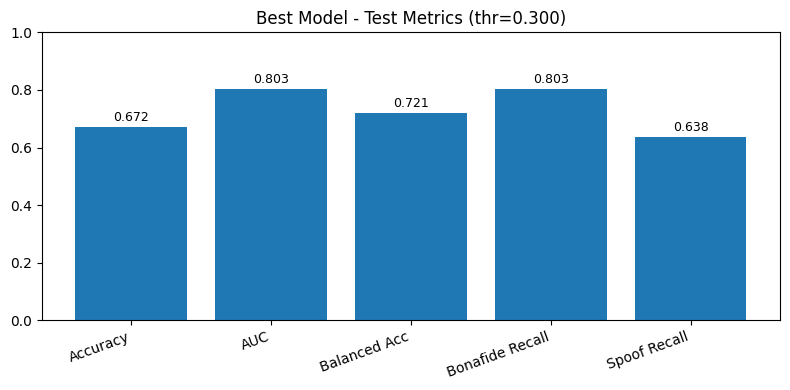

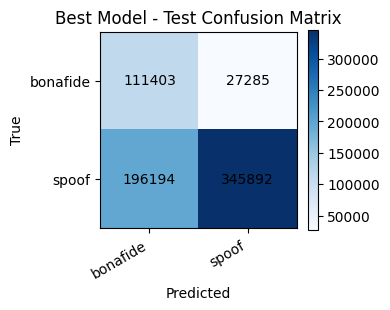

In [3]:
# Best model only: Test metrics at the chosen (best) threshold from run_summary.json
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path(
    "/home/SpeakerRec/BioVoice/data/models/asvspoof5_all_data_train_dev_eval_streaming_binary"
)
s = json.loads((OUT_DIR / "run_summary.json").read_text())

best = s["best_params"]
m = s["metrics_test_tuned_threshold"]  # this is the best model operating point

print("Best threshold (from val/dev):", round(best["threshold"], 4))
print("Test accuracy:", round(m["accuracy"], 4))
print("Test AUC:", round(m["auc"], 4))
print("Test balanced accuracy:", round(m["balanced_accuracy"], 4))
print("Bonafide recall:", round(m["bonafide_recall"], 4))
print("Spoof recall:", round(m["spoof_recall"], 4))
print("Confusion matrix:", m["confusion_matrix"])

# 1) Single-bar chart for best test metrics
metric_names = ["Accuracy", "AUC", "Balanced Acc", "Bonafide Recall", "Spoof Recall"]
metric_vals = [
    m["accuracy"],
    m["auc"],
    m["balanced_accuracy"],
    m["bonafide_recall"],
    m["spoof_recall"],
]

plt.figure(figsize=(8, 4))
bars = plt.bar(metric_names, metric_vals)
plt.ylim(0, 1)
plt.title(f"Best Model - Test Metrics (thr={best['threshold']:.3f})")
plt.xticks(rotation=20, ha="right")
for b, v in zip(bars, metric_vals):
    plt.text(
        b.get_x() + b.get_width() / 2,
        v + 0.01,
        f"{v:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

# 2) Confusion matrix for best model only
cm = np.array(m["confusion_matrix"])
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["bonafide", "spoof"], rotation=30, ha="right")
ax.set_yticklabels(["bonafide", "spoof"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Best Model - Test Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()